In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')

In [35]:
class Weibull:
    def __init__(self, b, k, eps=1e-8):
        # b and k are strictly positive tensors of the same shape
        self.b = b
        self.k = k
        self.eps = eps
    
    def log_prob(self, x):
        """Logarithm of the probability density function log(f(x))."""
        # x must have the same shape as self.b and self.k
        x = x.clamp_min(self.eps)  # pow is unstable for inputs close to 0
        return (self.b.log() + self.k.log() + (self.k - 1) * x.log() 
                + self.b.neg() * torch.pow(x, self.k))
    
    def log_survival(self, x):
        """Logarithm of the survival function log(S(x))."""
        x = x.clamp_min(self.eps)  # pow is unstable for inputs close to 0
        return self.b.neg() * torch.pow(x, self.k)

In [36]:
plt.rcParams.update({
    "text.usetex": True,
})

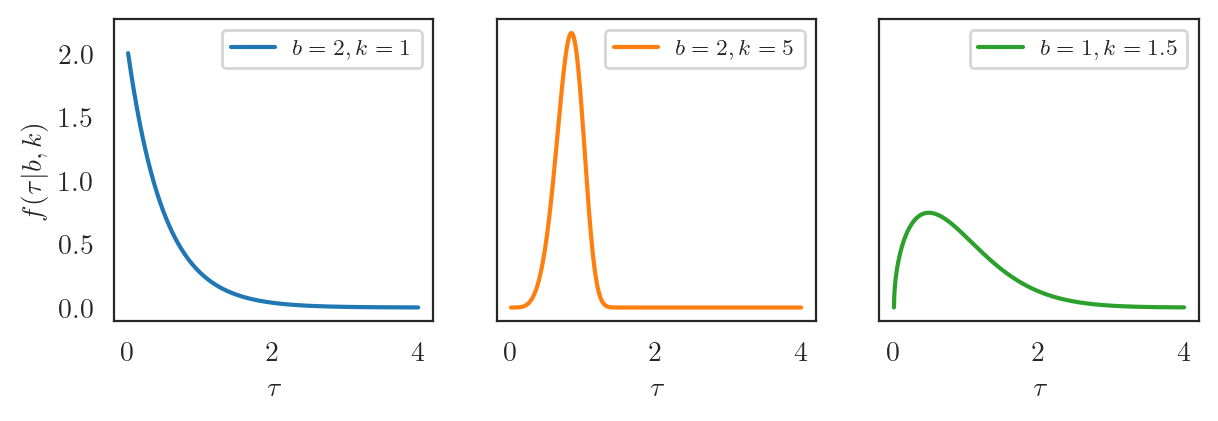

In [63]:
fig, axes = plt.subplots(ncols=3, dpi=200, figsize=[7, 2], sharey=True)

params = [
    [2, 1],
    [2, 5],
    [1, 1.5],
]

for i, ax in enumerate(axes):
    b, k = params[i]
    p = Weibull(torch.tensor(b), torch.tensor(k))
    x = torch.linspace(0, 4, 1000)
    y = p.log_prob(x).exp().numpy()
    ax.plot(x.numpy(), y, label=f"$b = {b}, k = {k}$", color=f"C{i}")
    ax.legend(fontsize=8)
    ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$f(\tau | b, k)$")
fig.savefig("/Users/shchur/Documents/blog/assets/img/posts/tpp2/weibull.png")